<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> Mid-Term Assignment - CSV to Data Warehouse </b></h3>

<div style="background-color:#f8f9fa; padding:15px; border-radius:10px; border:1px solid #FF8DA1;">
<h3><b> Table of Contents</b></h3>

1. [Introduction and Selection of Dataset](#introduction)
2. [Libraries and Environment Setup](#libraries)
3. [Data Loading and Merging](#load)
4. [Data Cleaning](#clean)
5. [Star Schema: Dimensions Construction](#dimensions)
5. [Fact Table Construction](#fact-table)
6. [SQL Database Export](#sql)
7. [Exploratory Data Analysis (SQL Queries)](#analysis)
8. [Visual Insights (Seaborn)](#visuals)
</div>

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="introduction"></a> Introduction and Selection of Dataset </b></h3>

### **Introduction & Project Goals**

The primary goal of this project is to build a **Star Schema Data Warehouse** by transforming a raw CSV dataset using **Python and SQLite**. This work focuses on the entire ETL cycle: extracting raw data, transforming formats, and loading them into a **centralized analytical database** for the movie industry.


### **Dataset Selection**

After evaluating all the three dataset options, the **TMDB 5000 Movies Dataset** was selected out of the list for the following reasons:

- **Meaningful Insights**: The variety of attributes allows for creative and especially useful business insights, such as comparing success across different genres or directors and if the movie's release date is a key factor in a movie's sucess, helping determine the best timing for future releases.

- **Dataset Structure**: The way the data is organized made it a really good option to build a solid Star Schema with a clear Fact table and meaningful Dimensions.

- **Personal Interest in the Theme**: Working with movie data is much more engaging and intuitive than medical records or music technicalities, making the analysis process more interesting for our group.

### TMDB Movie Metadata — Movies Table

| Column | Description |
|--------|-------------|
| budget | Estimated production budget of the movie |
| genres | List of movie genres (stored as JSON-like text) |
| homepage | Official movie homepage URL, if available |
| id | Unique identifier for the movie |
| keywords | List of plot-related keywords/tags |
| original_language | Original language of the movie |
| original_title | Original title of the movie |
| overview | Short summary or description of the movie |
| popularity | Popularity score assigned by TMDB |
| production_companies | List of production companies involved |
| production_countries | List of countries where the movie was produced |
| release_date | Official release date of the movie |
| revenue | Total revenue generated by the movie |
| runtime | Duration of the movie in minutes |
| spoken_languages | Languages spoken in the movie |
| status | Release status (e.g., Released) |
| tagline | Promotional slogan or tagline |
| title | Display title of the movie |
| vote_average | Average user rating |
| vote_count | Number of user votes received |

### TMDB Movie Metadata — Credits Table

| Column | Description |
|--------|-------------|
| movie_id | Unique identifier linking the credits to a movie |
| title | Title of the movie |
| cast | List of cast members (stored as JSON-like text) |
| crew | List of crew members such as director, producer, etc. |

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="libraries"></a> Libraries and Environment Setup </b></h3>

In [1]:
import pandas as pd
import numpy as np
import ast #allow us to explode information in a json format
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns



#display configuration to avoid scientific notation (e+09)
pd.options.display.float_format = '{:.2f}'.format

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="load"></a> Data Loading and Merging </b></h3>

The TMDB 5000 dataset is provided as two separate CSV files. 
One containing **general movie data**, such as budget, revenue, genres (df_1) and another containing **specific credits** , like cast and crew (df_2). The first step was to load both files and **merge them into a single DataFrame**. We performed this merge using the **unique movie ID** present in both files. 


This was a crucial step to ensure that, later on, the metrics could be correctly linked to each other. 

In [2]:
#loading datasets
df_1 = pd.read_csv('tmdb_5000_movies.csv')
df_2 = pd.read_csv('tmdb_5000_credits.csv')


#merging based on the unique ID
#the 'id' in df_1 and 'movie_id' in df_2 are the same entity
df_combined = pd.merge(df_1, df_2, left_on = 'id', right_on = 'movie_id')

#cleaning up redundant information after merging
df_combined.drop(columns= ['movie_id', 'title_y'], inplace = True)
df_combined.rename(columns= {'title_x' : 'title'}, inplace= True)

In [3]:
#quick exploration
print(f"Dataset Dimensions: {df_combined.shape}")

Dataset Dimensions: (4803, 22)


<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="clean"></a> Data Cleaning ( Missing Values, Duplicate Records, Change Datatypes) </b></h3>

#### **Handling Missing Values**

Having missing values in our fact table and/or dimensions can be a large problem because it directly affects the accuracy of some business metrics and the reliability of our SQL joins.

In [4]:
df_combined.isna().sum() #to check the missing values per columns

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                       0
crew                       0
dtype: int64

In [5]:
'''
In the case of release_date and runtime which only have 1 and 2 missing values,
respectively, we chose to drop these rows.
Since the dataset contains 4803 records, losing 3 rows (less than 0.1% of the data) 
is insignificant and ensures that the dimensions remain accurate
without having to impute or guess these values.
'''

df_combined = df_combined.dropna(subset=['release_date'])
df_combined = df_combined.dropna(subset=['runtime'])

In [6]:
#dropping columns that are not necessary for the Star Schema
#by dropping, we focus only on the attributes that drive meaningful insights

df_combined.drop(columns = ['homepage', 'tagline', 'overview', 'keywords', 'status'], inplace = True)

#### **Handling Duplicate Records**

In [7]:
#checking for duplicate records
duplicate_count = df_combined.duplicated().sum()
print(f"Number of duplicate records found: {duplicate_count}")

Number of duplicate records found: 0


#### **Checking Data Types**

In [8]:
df_combined.dtypes

budget                    int64
genres                   object
id                        int64
original_language        object
original_title           object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
title                    object
vote_average            float64
vote_count                int64
cast                     object
crew                     object
dtype: object

In [9]:
#change some data types to allow a better analysis
df_combined['release_date'] = pd.to_datetime(df_combined['release_date'])
df_combined['budget'] = pd.to_numeric(df_combined['budget'], errors='coerce')
df_combined['revenue'] = pd.to_numeric(df_combined['revenue'], errors='coerce')

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="dimension" ></a>Star Schema: Dimensions Construction </b></h3>

In this stage of the project, we will separate the dataset into **five distinct Dimension tables**. 

Each dimension was carefully selected to answer **specific business questions regarding movie success**:


- **Dimension 1 - Dates**: Essential for **Time-Series analysis**. It allows us to see if movies released in specific months or quarters perform better financially.
- **Dimension 2 - Genres**: Developed by "exploding" the nested JSON strings. This allows us to attribute a single movie's success to multiple genres (e.g., Action and Comedy).
- **Dimension 3 - Language**: Used to analyze the reach of the movie and whether the original language impacts the global popularity score.
- **Dimension 4 - Cast**: Contains the actors involved in the production, enabling us to identify which "star power" correlates with higher box office revenue.
- **Dimension 5 - Production Companies**: I chose to filter the crew list specifically for Directors. This simplifies the model while keeping the most influential creative role for profit and ROI analysis.

### **Dimension 1 - Dates**

The Date Dimension is the centre of any time-series analysis. By extracting the year, month, and day name from the raw release date, we can identify **seasonal trends**.

In [10]:
dim1_date = pd.DataFrame({
    'movie_id': df_combined['id'],
    'release_date': df_combined['release_date'],
    'year': pd.to_datetime(df_combined['release_date']).dt.year,
    'month': pd.to_datetime(df_combined['release_date']).dt.month,
    'quarter': pd.to_datetime(df_combined['release_date']).dt.quarter,
    'day_of_week': pd.to_datetime(df_combined['release_date']).dt.day_name()
})

In [11]:
dim1_date #just to check

,movie_id,release_date,year,month,quarter,day_of_week
0,19995,2009-12-10,2009,12,4,Thursday
1,285,2007-05-19,2007,5,2,Saturday
2,206647,2015-10-26,2015,10,4,Monday
3,49026,2012-07-16,2012,7,3,Monday
4,49529,2012-03-07,2012,3,1,Wednesday
...,...,...,...,...,...,...
4798,9367,1992-09-04,1992,9,3,Friday
4799,72766,2011-12-26,2011,12,4,Monday
4800,231617,2013-10-13,2013,10,4,Sunday
4801,126186,2012-05-03,2012,5,2,Thursday


### **Dimension 2 - Genres**

Since a movie can belong to multiple categories, this dimension was created by **"exploding" the nested JSON data**. With this information, we can **compare the profitability and popularity** across different cinematic styles, such as Action, Comedy, or Documentary.

In [12]:
df_combined['genres'] = df_combined['genres'].apply(ast.literal_eval)
df_genres_exploded = df_combined[['id', 'genres']].explode('genres')
df_genres_exploded = df_genres_exploded.dropna(subset=['genres'])
df_genres_exploded 

,id,genres
0,19995,"{'id': 28, 'name': 'Action'}"
0,19995,"{'id': 12, 'name': 'Adventure'}"
0,19995,"{'id': 14, 'name': 'Fantasy'}"
0,19995,"{'id': 878, 'name': 'Science Fiction'}"
1,285,"{'id': 12, 'name': 'Adventure'}"
...,...,...
4800,231617,"{'id': 35, 'name': 'Comedy'}"
4800,231617,"{'id': 18, 'name': 'Drama'}"
4800,231617,"{'id': 10749, 'name': 'Romance'}"
4800,231617,"{'id': 10770, 'name': 'TV Movie'}"


In [13]:
dim_genres = pd.DataFrame({
    'movie_id': df_genres_exploded['id'],
    'genre_id': df_genres_exploded['genres'].apply(lambda x: x['id']),
    'genre_name': df_genres_exploded['genres'].apply(lambda x: x['name'])})
dim_genres

,movie_id,genre_id,genre_name
0,19995,28,Action
0,19995,12,Adventure
0,19995,14,Fantasy
0,19995,878,Science Fiction
1,285,12,Adventure
...,...,...,...
4800,231617,35,Comedy
4800,231617,18,Drama
4800,231617,10749,Romance
4800,231617,10770,TV Movie


### **Dimension 3 - Cast**

This fourth dimension stores the lead actors involved in each production. We can measure "Star Power" and analyze how the presence of **specific actors influences the movie’s overall popularity and revenue**.

In [14]:
df_combined['cast'] = df_combined['cast'].apply(ast.literal_eval)
df_cast_exploded = df_combined[['id', 'cast']].explode('cast')
df_cast_exploded = df_cast_exploded.dropna(subset=['cast'])
df_cast_exploded

,id,cast
0,19995,"{'cast_id': 242, 'character': 'Jake Sully', 'c..."
0,19995,"{'cast_id': 3, 'character': 'Neytiri', 'credit..."
0,19995,"{'cast_id': 25, 'character': 'Dr. Grace August..."
0,19995,"{'cast_id': 4, 'character': 'Col. Quaritch', '..."
0,19995,"{'cast_id': 5, 'character': 'Trudy Chacon', 'c..."
...,...,...
4802,25975,"{'cast_id': 8, 'character': 'Himself', 'credit..."
4802,25975,"{'cast_id': 9, 'character': 'Himself', 'credit..."
4802,25975,"{'cast_id': 10, 'character': 'Himself', 'credi..."
4802,25975,"{'cast_id': 11, 'character': 'Himself', 'credi..."


In [15]:
dim3_cast = pd.DataFrame({
    'movie_id': df_cast_exploded['id'],
    'actor_id': df_cast_exploded['cast'].apply(lambda x: x['id']),
    'actor_name': df_cast_exploded['cast'].apply(lambda x: x['name']),
    'character': df_cast_exploded['cast'].apply(lambda x: x['character'])
})

In [16]:
dim3_cast

,movie_id,actor_id,actor_name,character
0,19995,65731,Sam Worthington,Jake Sully
0,19995,8691,Zoe Saldana,Neytiri
0,19995,10205,Sigourney Weaver,Dr. Grace Augustine
0,19995,32747,Stephen Lang,Col. Quaritch
0,19995,17647,Michelle Rodriguez,Trudy Chacon
...,...,...,...,...
4802,25975,21315,Eric Roberts,Himself
4802,25975,2171,Griffin Dunne,Himself
4802,25975,2231,Samuel L. Jackson,Himself
4802,25975,14407,Matt LeBlanc,Himself


### **Dimension 4 - Production Companies**

In [17]:
df_combined['production_companies'] = df_combined['production_companies'].apply(ast.literal_eval)
df_production_exploded = df_combined[['id', 'production_companies']].explode('production_companies')
df_production_exploded = df_production_exploded.dropna(subset=['production_companies'])

dim4_production = pd.DataFrame({
    'movie_id': df_production_exploded['id'],
    'company_id': df_production_exploded['production_companies'].apply(lambda x: x['id']),
    'company_name': df_production_exploded['production_companies'].apply(lambda x: x['name'])
})

dim4_production.head()

,movie_id,company_id,company_name
0,19995,289,Ingenious Film Partners
0,19995,306,Twentieth Century Fox Film Corporation
0,19995,444,Dune Entertainment
0,19995,574,Lightstorm Entertainment
1,285,2,Walt Disney Pictures


<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="dimension" ></a>Fact Table</b></h3>

In [18]:
fact_table = df_combined[['id','budget','revenue', 'runtime', 'popularity', 'vote_average','vote_count']]
fact_table['revenue'] = fact_table['revenue'].replace(0, np.nan)
fact_table['budget'] = fact_table['budget'].replace(0, np.nan)

#create columns
fact_table['profit'] = fact_table['revenue'] - fact_table['budget']
fact_table['ROI'] = fact_table['profit'] / fact_table['budget']

# Standardize the ID name
fact_table.rename(columns={'id': 'movie_id'}, inplace=True)

C:\Users\tiago\AppData\Local\Temp\ipykernel_2452\446896283.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_table['revenue'] = fact_table['revenue'].replace(0, np.nan)
C:\Users\tiago\AppData\Local\Temp\ipykernel_2452\446896283.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_table['budget'] = fact_table['budget'].replace(0, np.nan)
C:\Users\tiago\AppData\Local\Temp\ipykernel_2452\446896283.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

In [19]:
fact_table

,movie_id,budget,revenue,runtime,popularity,vote_average,vote_count,profit,ROI
0,19995,237000000.00,2787965087.00,162.00,150.44,7.20,11800,2550965087.00,10.76
1,285,300000000.00,961000000.00,169.00,139.08,6.90,4500,661000000.00,2.20
2,206647,245000000.00,880674609.00,148.00,107.38,6.30,4466,635674609.00,2.59
3,49026,250000000.00,1084939099.00,165.00,112.31,7.60,9106,834939099.00,3.34
4,49529,260000000.00,284139100.00,132.00,43.93,6.10,2124,24139100.00,0.09
...,...,...,...,...,...,...,...,...,...
4798,9367,220000.00,2040920.00,81.00,14.27,6.60,238,1820920.00,8.28
4799,72766,9000.00,NaN,85.00,0.64,5.90,5,NaN,NaN
4800,231617,NaN,NaN,120.00,1.44,7.00,6,NaN,NaN
4801,126186,NaN,NaN,98.00,0.86,5.70,7,NaN,NaN


<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="dimension" ></a>SQL Queries </b></h3>

In [20]:
conn = sqlite3.connect('movies_warehouse.db')
cursor = conn.cursor()

cursor.executescript('''
DROP TABLE IF EXISTS dim_date;
DROP TABLE IF EXISTS dim_genres;
DROP TABLE IF EXISTS dim_language;
DROP TABLE IF EXISTS dim_cast;
DROP TABLE IF EXISTS dim_crew;
DROP TABLE IF EXISTS fact_table;
''')

#this is the creation of our fact table
#movie_id is the primary key
cursor.execute('''
CREATE TABLE fact_table (
    movie_id INTEGER PRIMARY KEY,
    budget REAL,
    revenue REAL,
    runtime REAL,
    popularity REAL,
    vote_average REAL,
    vote_count INTEGER,
    profit REAL,
    ROI REAL
)
''')

#creation of dimensions
#dimension 1 - dates
#movie_id is a foreign key that is connected to movie_id on fact_table
cursor.execute('''
CREATE TABLE dim_date (
    movie_id INTEGER,
    release_date TEXT,
    year INTEGER,
    month INTEGER,
    quarter INTEGER,
    day_of_week TEXT,
    FOREIGN KEY (movie_id) REFERENCES fact_table (movie_id)
)
''')


#dimension 2 - genres
#movie_id is a foreign key that is connected to movie_id on fact_table
cursor.execute('''
CREATE TABLE dim_genres (
    movie_id INTEGER,
    genre_id INTEGER,
    genre_name TEXT,
    FOREIGN KEY (movie_id) REFERENCES fact_table (movie_id)
)
''')


#dimension 3 - cast
#movie_id is a foreign key that is connected to movie_id on fact_table
cursor.execute('''
CREATE TABLE dim_cast (
    movie_id INTEGER,
    actor_id INTEGER,
    actor_name TEXT,
    character TEXT,
    gender_label TEXT,
    FOREIGN KEY (movie_id) REFERENCES fact_table (movie_id)
)
''')

#dimension 4 - crew
#movie_id is a foreign key that is connected to movie_id on fact_table
cursor.execute('''
CREATE TABLE dim_crew (
    movie_id INTEGER,
    director_id INTEGER,
    director_name TEXT,
    job TEXT,
    gender_label TEXT,
    FOREIGN KEY (movie_id) REFERENCES fact_table (movie_id)
)
''')


fact_table.to_sql('fact_table', conn, index=False, if_exists='append')
dim1_date.to_sql('dim_date', conn, index=False, if_exists='append')
dim_genres.to_sql('dim_genres', conn, index=False, if_exists='append')
dim3_cast.to_sql('dim_cast', conn, index=False, if_exists='append')
dim4_production.to_sql('dim_production', conn, index=False, if_exists='append')

13675

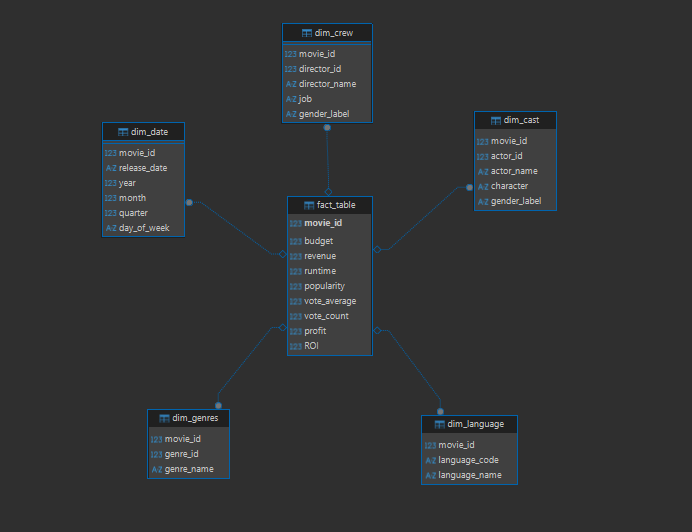

In [21]:
#Establish the connection
conn = sqlite3.connect('movies_warehouse.db')

#Query 1: Top 5 Most Profitable Production Companies
query_1 ="""
SELECT 
    p.company_name, 
    COUNT(f.movie_id) AS total_movies,
    ROUND(SUM(f.revenue), 2) AS total_revenue,
    ROUND(SUM(f.profit), 2) AS total_profit,
    ROUND(AVG(f.ROI), 2) AS average_roi
FROM fact_table f
JOIN dim_production p ON f.movie_id = p.movie_id
WHERE f.profit IS NOT NULL
GROUP BY p.company_name
HAVING total_movies >= 5
ORDER BY total_profit DESC
LIMIT 10;
"""


#Query 2: ROI by Budget Level
query_2 = '''
SELECT 
    CASE 
        WHEN budget >= 100000000 THEN '1. Mega Blockbuster ($100M+)'
        WHEN budget BETWEEN 50000000 AND 99999999 THEN '2. High Budget ($50M-$99M)'
        WHEN budget BETWEEN 10000000 AND 49999999 THEN '3. Mid Budget ($10M-$49M)'
        ELSE '4. Low Budget (< $10M)'
    END AS budget_tier,
    COUNT(movie_id) AS total_movies,
    ROUND(AVG(profit), 2) AS avg_profit,
    ROUND(AVG(ROI), 2) AS avg_roi
FROM fact_table
WHERE budget > 0 AND profit IS NOT NULL AND ROI IS NOT NULL
GROUP BY budget_tier
ORDER BY budget_tier;
'''


#revenue by genre
query_3 = '''
-- Query 3: Genre Profitability & Efficiency
SELECT 
    g.genre_name, 
    COUNT(f.movie_id) AS film_count,
    ROUND(AVG(f.profit), 2) AS avg_profit,
    ROUND(AVG(f.ROI), 2) AS avg_roi
FROM fact_table f
JOIN dim_genres g ON f.movie_id = g.movie_id
WHERE f.profit IS NOT NULL AND f.ROI IS NOT NULL
GROUP BY g.genre_name
HAVING film_count > 10
ORDER BY avg_roi DESC;
'''


#Query 4: Top 10 Actors by Average Audience Score
query_4 = '''-- Query 5: Top 10 Actors by Average Audience Score
SELECT 
    c.actor_name, 
    COUNT(f.movie_id) AS film_count,
    ROUND(AVG(f.vote_average), 2) AS avg_audience_score,
    SUM(f.vote_count) AS total_votes_received
FROM fact_table f
JOIN dim_cast c ON f.movie_id = c.movie_id
GROUP BY c.actor_name
HAVING film_count >= 5  -- Filtro para garantir consistência
ORDER BY avg_audience_score DESC
LIMIT 10;'''

#Query 5: Popularity by Day of the Week
query_5 = '''SELECT 
    d.day_of_week, 
    COUNT(f.movie_id) AS release_count,
    ROUND(AVG(f.popularity), 2) AS avg_popularity
FROM fact_table f
JOIN dim_date d ON f.movie_id = d.movie_id
GROUP BY d.day_of_week
ORDER BY avg_popularity DESC;
'''



print("--- TOP 10 PRODUCTION COMPANIES BY PROFIT ---")
display(pd.read_sql_query(query_1, conn))

print("\n--- ROI BY BUDGET LEVEL ---")
display(pd.read_sql_query(query_2, conn))

print('--- REVENUE BY GENRE ---')
display(pd.read_sql_query(query_3, conn))

print('--- ACTOR BY audience ---')
display(pd.read_sql_query(query_4, conn))

print('--- POPULARITY BY DAY OF THE WEEK ---')
display(pd.read_sql_query(query_5, conn))


# conn.close()

--- TOP 10 PRODUCTION COMPANIES BY PROFIT ---


,company_name,total_movies,total_revenue,total_profit,average_roi
0,Warner Bros.,1400,244110372815.00,154691903070.00,2.77
1,Universal Pictures,1365,211973016670.00,147546185305.00,4.44
2,Twentieth Century Fox Film Corporation,1005,195682508880.00,143213558880.00,4.51
3,Paramount Pictures,1225,202573629060.00,138744314025.00,4.52
4,Walt Disney Pictures,480,142578810790.00,96334910790.00,2.66
5,Columbia Pictures,835,142632673015.00,89858799335.00,1.88
6,New Line Cinema,710,96995052960.00,67967627960.00,8.39
7,Amblin Entertainment,235,80454175735.00,63025175735.00,5.71
8,DreamWorks SKG,335,71922668130.00,50160168130.00,2.35
9,Dune Entertainment,270,68171406035.00,48641406020.00,2.69



--- ROI BY BUDGET LEVEL ---


,budget_tier,total_movies,avg_profit,avg_roi
0,1. Mega Blockbuster ($100M+),318,305568971.28,1.99
1,2. High Budget ($50M-$99M),638,102205300.32,1.49
2,3. Mid Budget ($10M-$49M),1541,51920882.30,2.35
3,4. Low Budget (< $10M),732,24361082.97,13022.80


--- REVENUE BY GENRE ---


,genre_name,film_count,avg_profit,avg_roi
0,Comedy,1110,72323909.89,7662.07
1,Drama,1441,51943284.86,5907.02
2,Horror,332,47169591.48,3076.42
3,Thriller,935,69233752.75,1073.90
4,Documentary,38,20408259.53,159.11
5,Mystery,265,63308118.43,66.76
6,Music,111,55094011.84,5.44
7,Animation,188,198090651.16,5.09
8,Science Fiction,431,125956782.61,4.93
9,Fantasy,342,162675510.32,4.82


--- ACTOR BY audience ---


,actor_name,film_count,avg_audience_score,total_votes_received
0,Russ Fega,5,7.98,42144
1,Richard Bright,5,7.84,11911
2,Burnell Tucker,6,7.72,18441
3,Pete Docter,5,7.68,30874
4,Chuck Hamilton,5,7.68,2827
5,Gino Corrado,6,7.67,3088
6,Jack Purvis,5,7.66,18278
7,Joseph Oliveira,10,7.63,50902
8,Clem Caserta,5,7.60,7131
9,Harry Northup,5,7.54,8339


--- POPULARITY BY DAY OF THE WEEK ---


,day_of_week,release_count,avg_popularity
0,Wednesday,795,32.69
1,Tuesday,351,26.42
2,Thursday,915,24.70
3,Monday,233,20.99
4,Saturday,236,16.77
5,Friday,2053,16.27
6,Sunday,217,14.29


In [22]:
#Establish the connection
conn = sqlite3.connect('movies_warehouse.db')

#Query 1: Top 10 Most Profitable Production Companies
query_1 ="""
SELECT 
    p.company_name, 
    COUNT(f.movie_id) AS total_movies,
    ROUND(SUM(f.revenue), 2) AS total_revenue,
    ROUND(SUM(f.profit), 2) AS total_profit,
    ROUND(AVG(f.ROI), 2) AS average_roi
FROM fact_table f
JOIN dim_production p ON f.movie_id = p.movie_id
WHERE f.profit IS NOT NULL
GROUP BY p.company_name
HAVING total_movies >= 5
ORDER BY total_profit DESC
LIMIT 10;
"""

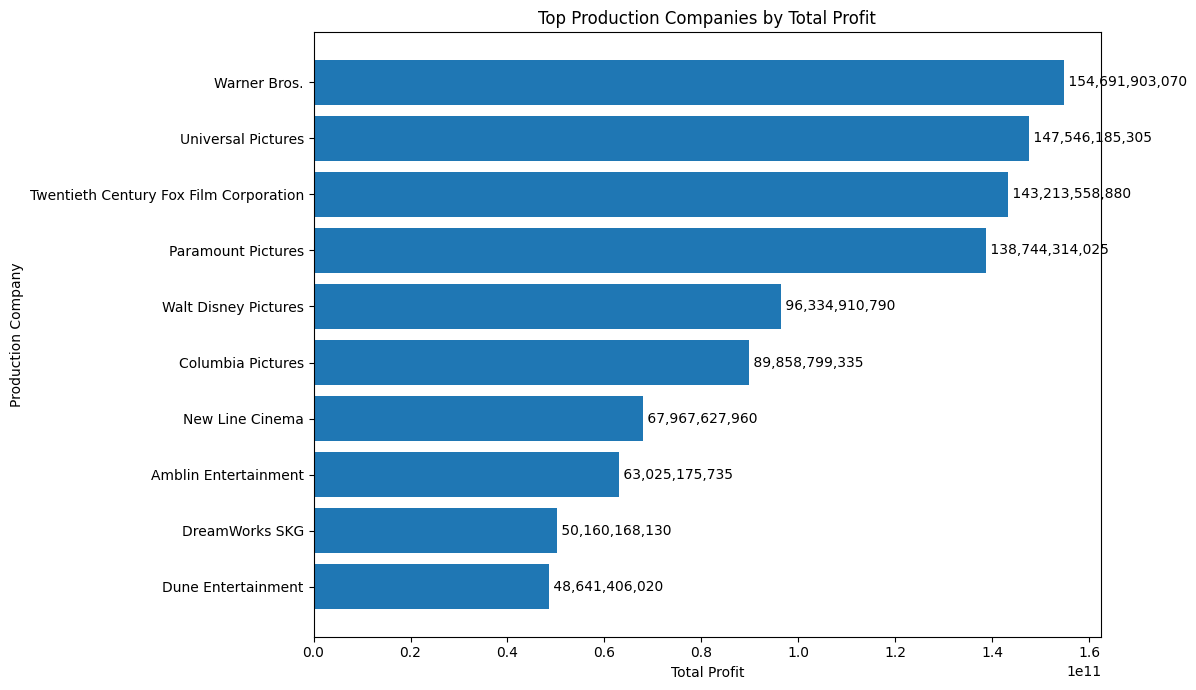

In [23]:
df_q1 = pd.read_sql_query(query_1, conn)

# Sort so the biggest bar appears at the top
df_q1 = df_q1.sort_values('total_profit', ascending=True)

# Plot
plt.figure(figsize=(12, 7))
plt.barh(df_q1['company_name'], df_q1['total_profit'])

plt.xlabel('Total Profit')
plt.ylabel('Production Company')
plt.title('Top Production Companies by Total Profit')

# Add value labels
for i, value in enumerate(df_q1['total_profit']):
    plt.text(value, i, f' {value:,.0f}', va='center')

plt.tight_layout()
plt.show()

analisar

In [24]:
#Query 2: ROI by Budget Level
query_2 = '''
SELECT 
    CASE 
        WHEN budget >= 100000000 THEN '1. Mega Blockbuster ($100M+)'
        WHEN budget BETWEEN 50000000 AND 99999999 THEN '2. High Budget ($50M-$99M)'
        WHEN budget BETWEEN 10000000 AND 49999999 THEN '3. Mid Budget ($10M-$49M)'
        ELSE '4. Low Budget (< $10M)'
    END AS budget_tier,
    COUNT(movie_id) AS total_movies,
    ROUND(AVG(profit), 2) AS avg_profit,
    ROUND(AVG(ROI), 2) AS avg_roi
FROM fact_table
WHERE budget > 0 AND profit IS NOT NULL AND ROI IS NOT NULL
GROUP BY budget_tier
ORDER BY budget_tier;
'''


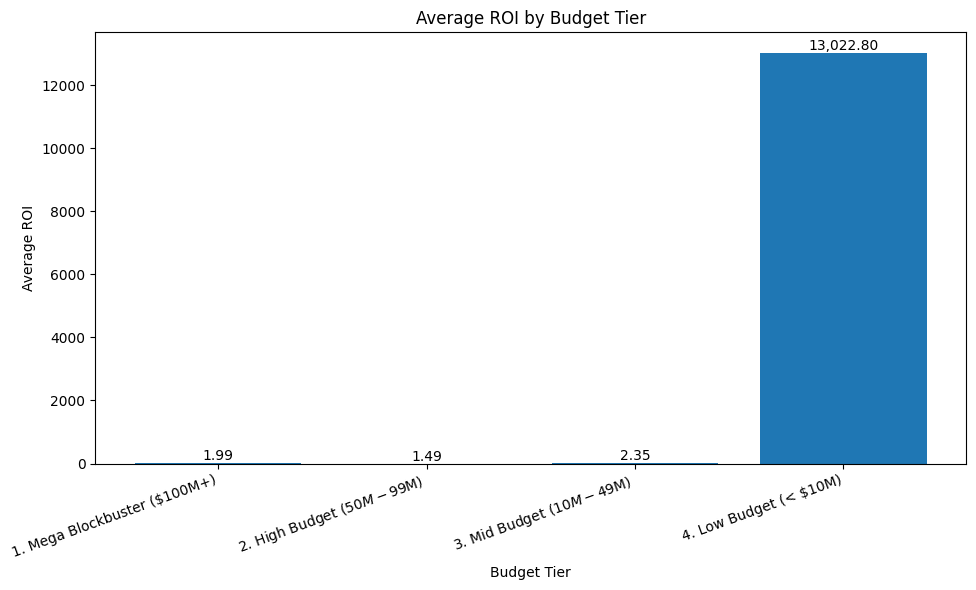

In [25]:
df_q2 = pd.read_sql_query(query_2, conn)

# Convert profit to millions for readability
df_q2['avg_profit_millions'] = df_q2['avg_profit'] / 1_000_000


plt.figure(figsize=(10, 6))
plt.bar(df_q2['budget_tier'], df_q2['avg_roi'])

plt.xlabel('Budget Tier')
plt.ylabel('Average ROI')
plt.title('Average ROI by Budget Tier')
plt.xticks(rotation=20, ha='right')

for i, value in enumerate(df_q2['avg_roi']):
    plt.text(i, value, f'{value:,.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

analisar

In [26]:
#revenue by genre
query_3 = '''
-- Query 3: Genre Profitability & Efficiency
SELECT 
    g.genre_name, 
    COUNT(f.movie_id) AS film_count,
    ROUND(AVG(f.profit), 2) AS avg_profit,
    ROUND(AVG(f.ROI), 2) AS avg_roi
FROM fact_table f
JOIN dim_genres g ON f.movie_id = g.movie_id
WHERE f.profit IS NOT NULL AND f.ROI IS NOT NULL
GROUP BY g.genre_name
HAVING film_count > 10
ORDER BY total_profit DESC;
'''

In [27]:
#gráfico para query 3

analisar 

In [28]:
#Top 10 Actors by Average Audience Score
query_4 = '''
SELECT 
    c.actor_name, 
    COUNT(f.movie_id) AS film_count,
    ROUND(AVG(f.vote_average), 2) AS avg_audience_score,
    SUM(f.vote_count) AS total_votes_received
FROM fact_table f
JOIN dim_cast c ON f.movie_id = c.movie_id
GROUP BY c.actor_name
HAVING film_count >= 5  -- Filtro para garantir consistência
ORDER BY avg_audience_score DESC
LIMIT 10;'''

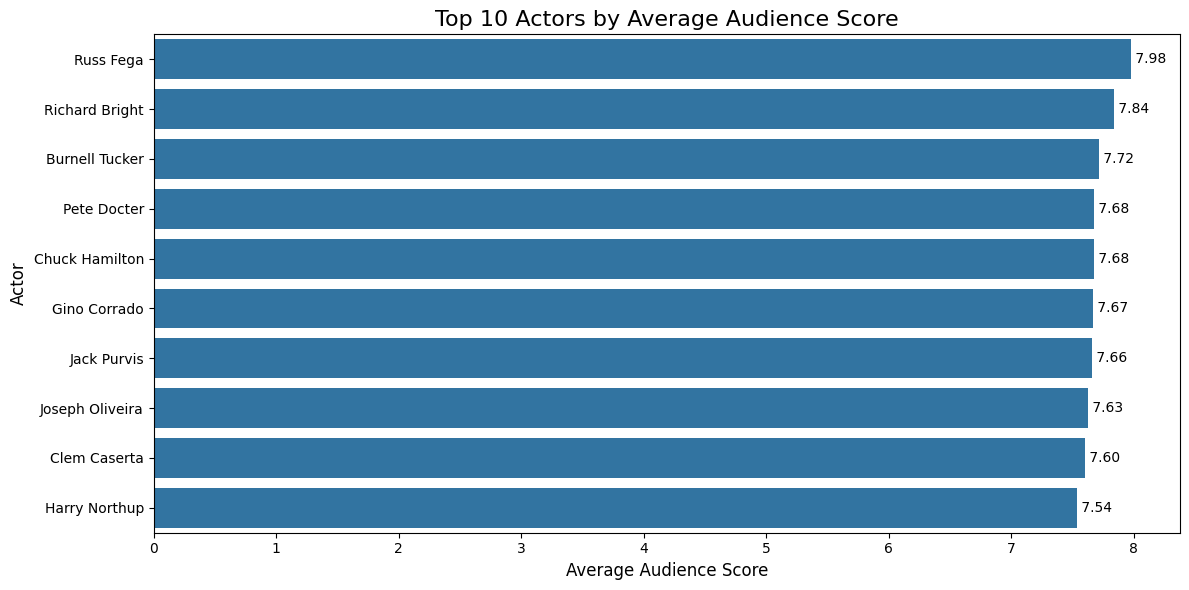

In [29]:
df_cast = pd.read_sql_query(query_4, conn)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_cast, x='avg_audience_score', y='actor_name')

plt.title('Top 10 Actors by Average Audience Score', fontsize=16)
plt.xlabel('Average Audience Score', fontsize=12)
plt.ylabel('Actor', fontsize=12)

for i, value in enumerate(df_cast['avg_audience_score']):
    ax.text(value, i, f' {value:.2f}', va='center')

plt.tight_layout()
plt.show()

In [30]:
query_5 = '''SELECT 
    d.day_of_week, 
    COUNT(f.movie_id) AS release_count,
    ROUND(AVG(f.popularity), 2) AS avg_popularity
FROM fact_table f
JOIN dim_date d ON f.movie_id = d.movie_id
GROUP BY d.day_of_week
ORDER BY avg_popularity DESC;
'''



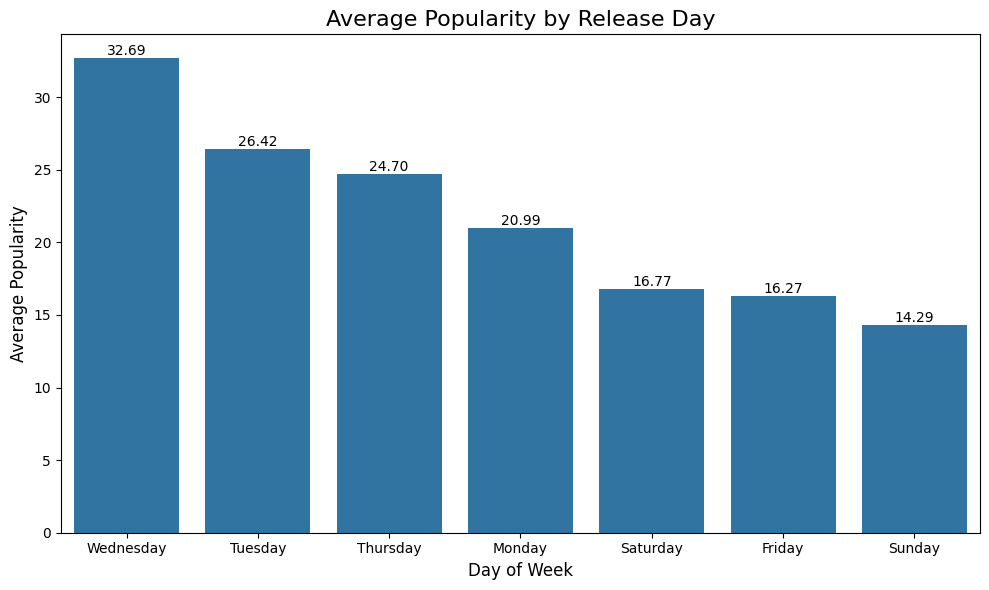

In [31]:
df_days = pd.read_sql_query(query_5, conn)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_days, x='day_of_week', y='avg_popularity')

plt.title('Average Popularity by Release Day', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Popularity', fontsize=12)

for i, value in enumerate(df_days['avg_popularity']):
    ax.text(i, value, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


analisar

In [32]:
conn.close()

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="dimension" ></a>Conclusion </b></h3>

In this project, we transformed the TMDB movie dataset into a structured data warehouse using a fact table and dimension tables.

We conducted this transformation and organized into a star schema in order to make the data easier to query, analyze and understand, and therefore, extract more meaningful insights

From our analysis, we can observe the movies' genre "Adventure" is the one with the highest revenue. Also, as an interesting observation, we can point out that the "Drama" genre, although it has the highest number of movies, it is only placed on 4th, having other genres like "Action" and "Comedy", which have a number of total movies way smaller.